# Manufacturing Sensor Anomaly Detection

**Objective:** Flag abnormal equipment windows using temperature, vibration, pressure, current, acoustic level, and flow measurements.

This notebook trains without labels. A small injected scenario flag is retained only to test the alerting workflow after scoring.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate normal behavior and rare stress scenarios


In [2]:
FEATURES = ["temperature_c", "vibration_mm_s", "pressure_bar", "motor_current_a", "acoustic_db", "flow_lpm"]
MEANS = np.asarray([68, 2.1, 8.4, 14, 62, 118], dtype=float)
STDS = np.asarray([4, 0.5, 0.7, 1.8, 3, 9], dtype=float)
SHIFTS = np.asarray([5, 9, -5, 6, 7, -6], dtype=float)

normal = rng.normal(MEANS, STDS, size=(960, len(FEATURES)))
stress = rng.normal(MEANS + SHIFTS * STDS, STDS * 0.55, size=(40, len(FEATURES)))
values = np.vstack([normal, stress])
values = np.maximum(values, 0)
data = pd.DataFrame(values, columns=FEATURES)
data["scenario_anomaly"] = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(stress), dtype=int)]
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset: {len(data):,} windows | stress scenarios retained for retrospective checks: {data['scenario_anomaly'].sum()}")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset: 1,000 windows | stress scenarios retained for retrospective checks: 40


,temperature_c,vibration_mm_s,pressure_bar,motor_current_a,acoustic_db,flow_lpm,scenario_anomaly
0,67.829,2.306,7.892,14.665,64.005,111.973,0
1,62.313,1.752,7.697,15.310,62.512,105.485,0
2,69.333,1.021,8.374,12.164,62.304,108.300,0
3,73.238,2.770,8.762,13.181,61.282,110.763,0
4,66.238,2.761,8.863,14.029,60.617,114.101,0


,count,mean,std,min,25%,50%,75%,max
temperature_c,1000.0,68.778,5.554,55.708,65.542,68.197,70.905,93.963
vibration_mm_s,1000.0,2.257,1.034,0.276,1.743,2.117,2.437,7.295
pressure_bar,1000.0,8.232,0.980,3.946,7.808,8.351,8.812,10.669
motor_current_a,1000.0,14.499,2.740,8.401,12.905,14.067,15.527,27.976
acoustic_db,1000.0,62.863,5.049,52.569,60.109,62.160,64.281,85.632
flow_lpm,1000.0,115.657,13.568,54.975,110.769,117.826,123.314,146.619


## 3. Robust scaling and label-free detector fitting


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(data[FEATURES])
contamination = 0.04

isolation = IsolationForest(n_estimators=240, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
data["isolation_flag"] = (isolation.fit_predict(X) == -1).astype(int)
data["isolation_score"] = -isolation.score_samples(X)

lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
data["lof_flag"] = (lof.fit_predict(X) == -1).astype(int)
data["lof_score"] = -lof.negative_outlier_factor_
print(f"Isolation Forest alerts: {data['isolation_flag'].sum()} | LOF alerts: {data['lof_flag'].sum()}")


Isolation Forest alerts: 40 | LOF alerts: 40


## 4. Retrospective detector diagnostics


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

rows = []
for name in ["isolation", "lof"]:
    rows.append({
        "detector": name,
        "precision": precision_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "recall": recall_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "f1": f1_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "roc_auc_from_score": roc_auc_score(data["scenario_anomaly"], data[f"{name}_score"]),
    })
diagnostics = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(diagnostics.round(4))
print("Scenario labels were not used during scaling, detector fitting, or threshold selection.")


Scenario labels were not used during scaling, detector fitting, or threshold selection.


,detector,precision,recall,f1,roc_auc_from_score
0,isolation,1.0,1.0,1.0,1.0000
1,lof,0.0,0.0,0.0,0.2011


## 5. Alert queue and feature-level context


In [5]:
median = data[FEATURES].median()
mad = (data[FEATURES] - median).abs().median().replace(0, 1e-9)
robust_deviation = ((data[FEATURES] - median) / mad).abs()
data["largest_deviation_feature"] = robust_deviation.idxmax(axis=1)
data["largest_robust_deviation"] = robust_deviation.max(axis=1)
alerts = data.sort_values("isolation_score", ascending=False).head(12)
display(alerts[FEATURES + ["isolation_score", "largest_deviation_feature", "largest_robust_deviation", "scenario_anomaly"]].round(3))


,temperature_c,vibration_mm_s,pressure_bar,motor_current_a,acoustic_db,flow_lpm,isolation_score,largest_deviation_feature,largest_robust_deviation,scenario_anomaly
388,83.953,6.192,5.155,22.049,85.021,54.975,0.720,vibration_mm_s,11.701,1
251,89.855,6.356,5.304,27.976,79.249,67.442,0.710,vibration_mm_s,12.171,1
561,85.874,6.196,4.986,26.397,83.335,57.155,0.709,vibration_mm_s,11.712,1
505,93.305,6.756,4.671,26.708,82.427,64.656,0.701,vibration_mm_s,13.320,1
117,89.014,7.155,4.968,27.223,83.293,64.111,0.700,vibration_mm_s,14.466,1
569,93.000,6.656,4.601,25.206,82.224,57.099,0.699,vibration_mm_s,13.035,1
237,90.883,6.435,4.793,23.278,81.047,61.437,0.695,vibration_mm_s,12.399,1
872,89.715,6.594,5.338,26.102,84.979,69.967,0.694,vibration_mm_s,12.855,1
792,93.963,6.269,4.415,23.852,82.830,68.434,0.692,vibration_mm_s,11.921,1
662,84.814,6.941,4.742,23.411,85.632,63.667,0.692,vibration_mm_s,13.853,1


## 6. Two-dimensional anomaly map


Detector score correlation: 0.4034


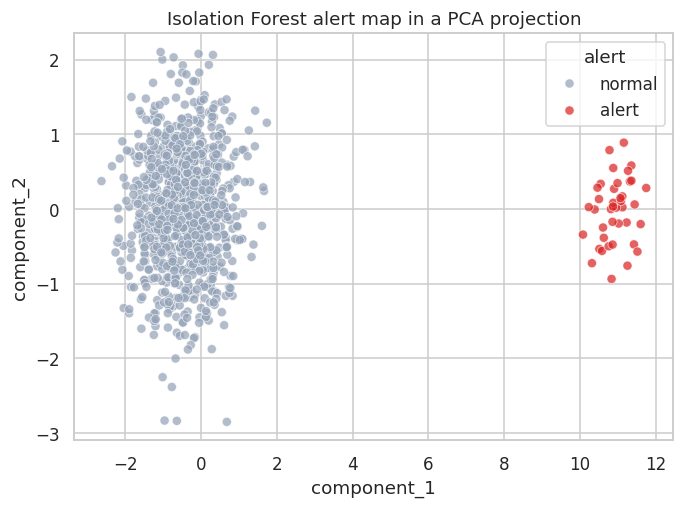

In [6]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "alert": data["isolation_flag"].map({0: "normal", 1: "alert"})})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="alert", palette={"normal": "#94a3b8", "alert": "#dc2626"}, alpha=0.72)
plt.title("Isolation Forest alert map in a PCA projection")
plt.tight_layout()
plt.show()
print(f"Detector score correlation: {data[['isolation_score', 'lof_score']].corr().iloc[0, 1]:.4f}")


## 7. Findings and limitations

- Anomaly scores prioritize investigation; they do not prove malicious activity, failure, or waste.
- The injected stress cases demonstrate evaluation mechanics only.
- Production thresholds should be calibrated to alert capacity, missed-event cost, seasonality, and feedback from investigators.
